
- 데이터: [KB부동산 데이터 허브](https://data.kbland.kr/) → KB 통계 → 주택가격동향조사
    - [주간 아파트 매매가격지수](https://data.kbland.kr/kbstats/wmh?tIdx=HT01&tsIdx=weekAptSalePriceInx) 전체('24년 10월 7일 기준)
    - [주간 아파트 전세가격지수](https://data.kbland.kr/kbstats/wmh?tIdx=HT01&tsIdx=weekAptRentPriceInx) 전체('24년 10월 7일 기준)

- 가격지수: 기준시점(22년 1월 10일) 대비 조사 시점(24년 10월)의 가격 비율 (주택별·지역별 가중)

# 데이터의 목표: 주택 매매가와 전세가격의 데이터를 확인해서 전세를 낀 매매를 통해 시세 차익을 도모한다.
## 세부목표 1: 주택 매매가 크게 상승하는 지역을 찾는다.
## 세부목표 2: 그 중 전세가격이 안정적으로 유지되거나 하락하는 지역을 찾는다.
## 세부목표 3: 해당 지역을 매매할 경우 몇 %의 수익률을 얻을 수 있을지 예측한다.

# 환경설정

In [1]:
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

# 데이터 불러오기
두 개의 엑셀파일을 읽어와서 각각 `df_sale`, `df_rent` 변수에 할당하고, shape을 확인

In [2]:
import pandas as pd

df_sale = pd.read_excel("./data/주간 아파트 매매가격지수_20260210.xlsx")
df_rent = pd.read_excel("./data/주간 아파트 전세가격지수_20260210.xlsx")

In [3]:
df_sale.shape, df_rent.shape

((282, 899), (282, 899))

데이터 불러오기

주간 단위 아파트 매매가격지수와 전세가격지수 데이터를 각각 불러온다.

이후 분석에서 두 지수의 기간·지역(컬럼) 정합성을 맞추기 위해, 먼저 데이터 크기(shape)를 확인한다

In [4]:
df_sale.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 282 entries, 0 to 281
Columns: 899 entries, 지역명 to 2026-02-02 00:00:52
dtypes: float64(1), object(898)
memory usage: 1.9+ MB


In [5]:
df_sale.columns

Index([              '지역명', 2008-04-07 00:00:52, 2008-04-14 00:00:52,
       2008-04-21 00:00:52, 2008-04-28 00:00:52, 2008-05-05 00:00:52,
       2008-05-12 00:00:52, 2008-05-19 00:00:52, 2008-05-26 00:00:52,
       2008-06-02 00:00:52,
       ...
       2025-12-01 00:00:52, 2025-12-08 00:00:52, 2025-12-15 00:00:52,
       2025-12-22 00:00:52, 2025-12-29 00:00:52, 2026-01-05 00:00:52,
       2026-01-12 00:00:52, 2026-01-19 00:00:52, 2026-01-26 00:00:52,
       2026-02-02 00:00:52],
      dtype='object', length=899)

In [6]:
df_sale['지역명'].unique()

array(['전국', '서울', '강북14개구', '종로구', '중구', '용산구', '성동구', '광진구', '동대문구',
       '중랑구', '성북구', '강북구', '도봉구', '노원구', '은평구', '서대문구', '마포구', '강남11개구',
       '양천구', '강서구', '구로구', '금천구', '영등포구', '동작구', '관악구', '서초구', '강남구',
       '송파구', '강동구', '수도권', '6개광역시', '5개광역시', '기타지방', '부산', '서구', '동구',
       '영도구', '부산진구', '동래구', '남구', '북구', '해운대구', '사하구', '금정구', '연제구',
       '수영구', '사상구', '기장군', '대구', '수성구', '달서구', '달성군', '인천', '미추홀구',
       '연수구', '남동구', '부평구', '계양구', '강화군', '광주', '광산구', '대전', '유성구', '대덕구',
       '울산', '울주군', '세종', '경기', '수원시', '수원시 장안구', '수원시 권선구', '수원시 팔달구',
       '수원시 영통구', '성남시', '성남시 수정구', '성남시 중원구', '성남시 분당구', '의정부시', '안양시',
       '안양시 만안구', '안양시 동안구', '부천시', '부천시 원미구', '부천시 소사구', '부천시 오정구',
       '광명시', '평택시', '동두천시', '안산시', '안산시 상록구', '안산시 단원구', '고양시',
       '고양시 덕양구', '고양시 일산동구', '고양시 일산서구', '과천시', '구리시', '남양주시', '오산시',
       '시흥시', '군포시', '의왕시', '하남시', '용인시', '용인시 처인구', '용인시 기흥구', '용인시 수지구',
       '파주시', '이천시', '안성시', '김포시', '화성시', '화성시 만세구', '화성시 효행구', '화성시 병점구'

In [7]:
df_sale.head(5)

,지역명,2008-04-07 00:00:52,2008-04-14 00:00:52,2008-04-21 00:00:52,2008-04-28 00:00:52,2008-05-05 00:00:52,2008-05-12 00:00:52,2008-05-19 00:00:52,2008-05-26 00:00:52,2008-06-02 00:00:52,...,2025-12-01 00:00:52,2025-12-08 00:00:52,2025-12-15 00:00:52,2025-12-22 00:00:52,2025-12-29 00:00:52,2026-01-05 00:00:52,2026-01-12 00:00:52,2026-01-19 00:00:52,2026-01-26 00:00:52,2026-02-02 00:00:52
0,전국,58.012546,58.088746,58.197535,58.281398,58.355038,58.427476,58.493162,58.553072,58.616457,...,90.563892,90.61607,90.669762,90.723634,90.780566,90.832983,90.896435,90.988497,91.076983,91.171226
1,서울,59.733068,59.88161,60.042211,60.163088,60.278446,60.387011,60.458109,60.525847,60.595353,...,103.430333,103.627722,103.80823,104.024977,104.25149,104.460231,104.710833,105.106874,105.440872,105.776555
2,강북14개구,59.738949,59.980174,60.250467,60.443754,60.625386,60.795838,60.908856,61.036939,61.155861,...,96.360463,96.505732,96.644737,96.808277,96.960962,97.152036,97.360009,97.724559,98.011018,98.310304
3,종로구,68.904068,69.003505,69.014767,69.06011,69.06011,69.019522,69.019522,69.060926,69.101609,...,105.373269,105.429936,105.540645,105.61693,105.694778,105.725094,105.817512,105.971637,106.03029,106.657303
4,중구,66.375784,66.420175,66.554633,66.66407,66.709373,66.709373,66.709373,66.709373,66.709373,...,108.51246,108.910689,109.1411,109.150096,109.274603,109.580119,109.884284,110.521498,110.709423,110.878716


데이터 구조 확인 및 컬럼별 특징, 개수 등 확인

In [8]:
df_sale_long = df_sale.melt(
    id_vars='지역명',
    var_name='날짜',
    value_name='매매지수'
)
df_sale_long['날짜'] = pd.to_datetime(df_sale_long['날짜'])
df_sale_long['연도'] = df_sale_long['날짜'].dt.year


df_sale_long


,지역명,날짜,매매지수,연도
0,전국,2008-04-07 00:00:52,58.012546,2008
1,서울,2008-04-07 00:00:52,59.733068,2008
2,강북14개구,2008-04-07 00:00:52,59.738949,2008
3,종로구,2008-04-07 00:00:52,68.904068,2008
4,중구,2008-04-07 00:00:52,66.375784,2008
...,...,...,...,...
253231,무주군,2026-02-02 00:00:52,110.667528,2026
253232,임실군,2026-02-02 00:00:52,109.431223,2026
253233,순창군,2026-02-02 00:00:52,103.264275,2026
253234,고창군,2026-02-02 00:00:52,119.761,2026


데이터 구조 변환 (Wide → Long)

지역별로 분리되어 있던 매매가격지수 데이터를
지역-날짜–지수-연도 형태의 long format으로 변환한다.

이를 통해 시계열 분석, 연도별 집계, 지역 간 수익률 비교가 가능하도록 데이터 구조를 정비한다.

In [9]:
df_sale_long.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 253236 entries, 0 to 253235
Data columns (total 4 columns):
 #   Column  Non-Null Count   Dtype         
---  ------  --------------   -----         
 0   지역명     253236 non-null  object        
 1   날짜      253236 non-null  datetime64[ns]
 2   매매지수    253236 non-null  object        
 3   연도      253236 non-null  int32         
dtypes: datetime64[ns](1), int32(1), object(2)
memory usage: 6.8+ MB


Long format 데이터 구조 확인

wide 형태에서 변환된 데이터의 행 수, 자료형, 결측치 여부를 점검한다.

특히 가격지수 컬럼이 자료형임을 확인하여 추가 전처리 필요 여부를 판단한다.

In [10]:
df_sale_long['매매지수'] = (
    df_sale_long['매매지수']
    .astype(str)
    .str.replace(',', '')
    .str.strip()
)

매매가격지수 문자열 정리

가격지수 컬럼에 포함된 문자열 요소를 정리하여
이후 숫자형 변환이 가능하도록 전처리를 수행한다.

쉼표(,) 제거 및 공백 제거를 통해 데이터 형식을 통일한다.

In [11]:
(df_sale_long['매매지수'] == '-').sum()

76913

In [12]:
(df_sale_long['매매지수'] == '-').mean()

0.303720640035382

결측·비정상 값(‘-’) 비율 확인

매매지수 컬럼에 포함된 ‘-’ 값을 집계하여
데이터 손실 규모를 정량적으로 확인한다.

In [13]:
missing_ratio = (
    (df_sale_long['매매지수'] == '-')
    .groupby(df_sale_long['지역명'])
    .mean()
    .sort_values(ascending=False)
)

missing_ratio.head(10)

지역명
화성시 효행구    0.998886
화성시 병점구    0.998886
화성시 만세구    0.998886
화성시 동탄구    0.998886
구례군        0.887528
순창군        0.887528
부천시 소사구    0.881960
부천시 원미구    0.881960
부천시 오정구    0.881960
횡성군        0.818486
Name: 매매지수, dtype: float64

지역별 결측·비정상 값 분포 확인

매매가격지수에 포함된 ‘-’ 값의 비율을 지역별로 집계하여
결측치가 특정 지역에 집중되어 있는지 확인한다.

이를 통해 단순 데이터 누락이 아닌
지수 산정 범위의 한계로 인한 구조적 결측 여부를 판단한다.

> 데이터에서 -로 되어 있는 값이 많아 최근 10년의 데이터만 활용하기로 정함.(집계가 안된 값이 너무 많음)

In [14]:
df_sale_long = df_sale.melt(id_vars='지역명',
                            var_name='날짜',
                            value_name='매매지수')

df_rent_long = df_rent.melt(id_vars='지역명',
                            var_name='날짜',
                            value_name='전세지수')

매매·전세 데이터 구조 통일

매매가격지수와 전세가격지수를 동일한 long format으로 변환하여
이후 병합 및 비교 분석이 가능하도록 데이터 구조를 통일한다.

In [15]:
df_sale_long['날짜'] = pd.to_datetime(df_sale_long['날짜'])
df_rent_long['날짜'] = pd.to_datetime(df_rent_long['날짜'])

날짜 컬럼 형식 통일

매매·전세 데이터의 날짜 컬럼을 datetime 형식으로 변환하여
시점 기준 병합 및 시계열 분석이 가능하도록 한다.

In [16]:
df_sale_long = df_sale_long[df_sale_long['날짜'].dt.year >= 2016]
df_rent_long = df_rent_long[df_rent_long['날짜'].dt.year >= 2016]

분석 기간 설정

장기 수익률 분석을 위해 최근 10년 수준의 데이터만을 사용한다.

데이터의 최신 시점을 기준으로 과거 기간을 제한하여 지역 간 비교의 일관성을 확보한다.

In [17]:
# 매매 기준
sale_dash_count = (df_sale_long['매매지수'] == '-').sum()
sale_dash_ratio = (df_sale_long['매매지수'] == '-').mean()

# 전세 기준
rent_dash_count = (df_rent_long['전세지수'] == '-').sum()
rent_dash_ratio = (df_rent_long['전세지수'] == '-').mean()

sale_dash_count, sale_dash_ratio, rent_dash_count, rent_dash_ratio

(34366, 0.24084041151571217, 34366, 0.24084041151571217)

매매·전세 지수의 비정상 값(‘-’) 비율 확인

매매가격지수와 전세가격지수에 포함된 ‘-’ 값의 개수와 비율을 확인하여
전처리 필요성을 정량적으로 점검한다.

In [18]:
df_sale_long['날짜'] = pd.to_datetime(df_sale_long['날짜'])

recent_sale = df_sale_long[df_sale_long['날짜'] >= '2016-01-01']

In [19]:
(recent_sale['매매지수'] == '-').mean()

0.24084041151571217

최근 기간 내 결측 비율 재확인

분석 기간(2016년 이후)으로 제한한 후에도 매매가격지수의 ‘-’ 값 비율이 어떻게 변화하는지 확인한다.

이를 통해 결측치가 특정 시점에만 집중된 문제인지, 혹은 지역 구조에 따른 문제인지를 판단한다.

In [20]:
recent_sale['is_dash'] = (recent_sale['매매지수'] == '-')

dash_by_region = (
    recent_sale
    .groupby('지역명')['is_dash']
    .mean()
    .sort_values(ascending=False)
)

dash_by_region.head(30)

지역명
화성시 효행구    0.998024
화성시 병점구    0.998024
화성시 만세구    0.998024
화성시 동탄구    0.998024
구례군        0.800395
순창군        0.800395
부천시 오정구    0.790514
부천시 원미구    0.790514
부천시 소사구    0.790514
정읍시        0.677866
부안군        0.677866
부여군        0.677866
횡성군        0.677866
정선군        0.677866
보은군        0.677866
사천시        0.677866
산청군        0.677866
봉화군        0.677866
밀양시        0.677866
보성군        0.677866
보령시        0.677866
상주시        0.677866
제주시        0.677866
문경시        0.677866
무주군        0.677866
무안군        0.677866
동해시        0.677866
영광군        0.677866
증평군        0.677866
진도군        0.677866
Name: is_dash, dtype: float64

최근 기간 기준 지역별 결측 비율 분석

최근 분석 기간(2016년 이후) 내에서 매매가격지수의 ‘-’ 값이 어떤 지역에 집중되어 있는지를 확인한다.

이를 통해 결측치가 시간 문제가 아닌 지역 단위의 구조적 문제임을 검증한다.

행정구조 개편 및 세분화 지역 신설에 따른 결측 문제

일부 지역(예: 화성시 만세구·효행구·병점구·동탄구)은 매매가격지수의 80~99% 이상이 ‘-’ 값으로 확인됨

이는 데이터 오류가 아니라, 행정구 분리·신설로 인해 과거 지수 자체가 존재하지 않기 때문

특히 신설·세분화된 지역은 장기 시계열 분석에 필요한 연속성이 확보되지 않음



>


1️⃣ 광역 단위 집계 지역 제외

전국, 수도권, 광역시 등 집계 목적의 상위 지역 단위는 분석 대상에서 제외

실제 투자 판단과 직접적으로 연결되는 기초 행정단위 중심 분석 수행

2️⃣ 신설·세분화 지역 제거

매매가격지수 기준
‘-’ 값 비율이 50% 이상인 지역은 분석 대상에서 제외

장기 가격 흐름을 설명하기에 데이터가 불충분하다고 판단

3️⃣ 최소 데이터 보유율 기준 설정

최근 10년 기준
전체 기간 중 80% 이상 지수가 존재하는 지역만 최종 분석에 활용

이를 통해 지역 간 수익률 비교의 신뢰도 확보

In [21]:
# 50% 이상 '-' 지역 제거

valid_regions = dash_by_region[dash_by_region < 0.5].index

recent_sale_clean = recent_sale[
    recent_sale['지역명'].isin(valid_regions)
].copy()

결측 비율 기준에 따른 분석 대상 지역 선정

지역별 ‘-’ 값 비율을 기준으로 데이터 연속성이 충분한 지역만 분석 대상에 포함한다.

본 분석에서는 매매가격지수 기준 결측 비율이 50% 미만인 지역만을 유지하였다.

In [22]:
# '-' → NaN → float 변환

import numpy as np

recent_sale_clean['매매지수'] = (
    recent_sale_clean['매매지수']
    .replace('-', np.nan)
    .astype(float)
)

C:\Users\Admin\AppData\Local\Temp\ipykernel_1944\2009017698.py:7: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .replace('-', np.nan)


매매가격지수 결측 처리 및 숫자형 변환

매매가격지수 컬럼에 포함된 ‘-’ 값을 결측치로 변환한 후,수치 연산이 가능하도록 숫자형(float)으로 변환한다.

이를 통해 수익률 계산 및 시계열 분석이 가능하도록 데이터 형태를 정비한다.

In [23]:
recent_sale_clean = recent_sale_clean.dropna(subset=['매매지수'])
recent_sale_clean['지역명'].nunique()

164

최종 분석 대상 데이터 확정

숫자형으로 변환된 매매가격지수 중 결측치(NaN)가 존재하는 관측치는 제거하여 분석의 정확성을 확보한다.

전처리 이후 최종적으로 분석에 활용 가능한 지역 수를 확인한다.

In [24]:
# 기간 수익률
recent_sale_clean = recent_sale_clean.sort_values(['지역명','날짜'])

recent_sale_clean['기간수익률'] = (
    recent_sale_clean
    .groupby('지역명')['매매지수']
    .pct_change()
)

시점 간 가격 변화율 계산

- 지역별로 연속된 관측 시점 간 매매가격지수의 변화율을 계산한다.
- 본 지표는 주간 데이터를 기반으로 하나, 결측 시점 제거로 인해 관측 간격이 일정하지 않을 수 있어
  ‘주간수익률’이 아닌 시점 간 변화율로 정의한다.

In [25]:
# 10년 누적 수익률
return_10y = (
    recent_sale_clean
    .groupby('지역명')['매매지수']
    .apply(lambda x: x.iloc[-1] / x.iloc[0] - 1)
    .sort_values(ascending=False)
)

return_10y.head(10)

지역명
성남시 분당구    1.221572
송파구        1.210351
강남구        1.125973
마포구        1.093169
양천구        1.051105
영등포구       1.035312
용산구        1.024985
성남시        1.024417
성동구        1.017357
광진구        0.991732
Name: 매매지수, dtype: float64

10년 누적 매매가격 수익률 계산

지역별로 분석 기간의 시작값과 종료값을 비교하여
**10년 누적 수익률(최종/최초 − 1)**을 산출한다.

지수 기반 수익률은 절대 가격이 아닌 상대적 변동 폭을 비교하는 목적이다.

한계: 16년 이후 데이터를 기준으로 했지만, 지수값이 없는 경우는 제외했기 때문에 10년이 아닐 수 있다.

In [26]:
top10_sale = (
    return_10y
    .sort_values(ascending=False)
    .head(10)
)

top10_sale

지역명
성남시 분당구    1.221572
송파구        1.210351
강남구        1.125973
마포구        1.093169
양천구        1.051105
영등포구       1.035312
용산구        1.024985
성남시        1.024417
성동구        1.017357
광진구        0.991732
Name: 매매지수, dtype: float64

매매가격 기준 장기 누적 수익률 상위 지역
- 분석 기간 동안 매매가격지수의 누적 상승률을 기준으로 상위 10개 지역을 선정하였다.
- 비교의 일관성을 위해 집계 단위(시 전체)는 제외하고, 기초 행정단위 중심으로 결과를 해석한다.

한계1: 데이터 값이 없는 경우 제외기 때문에 데이터가 있는 경우의 '분석기간 누적 수익률'입니다.
한계2: 성남시 분당구와 성남시가 혼재되어 있어 구단위로 분석되어 있지 않습니다.

In [27]:
# 최근 10년 데이터만 사용
recent_rent_clean = df_rent_long[df_rent_long['지역명'].isin(valid_regions)].copy()

# '-' → NaN → float 변환
recent_rent_clean['전세지수'] = recent_rent_clean['전세지수'].replace('-', np.nan).astype(float)
recent_rent_clean = recent_rent_clean.dropna(subset=['전세지수'])

# 매매와 전세 데이터 합치기
sale_rent = pd.merge(
    recent_sale_clean,
    recent_rent_clean[['지역명','날짜','전세지수']],
    on=['지역명','날짜'],
    how='inner'
)

# 상위 10개 지역 필터링
top10_data = sale_rent[sale_rent['지역명'].isin(top10_regions)].copy()

C:\Users\Admin\AppData\Local\Temp\ipykernel_1944\3878673967.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  recent_rent_clean['전세지수'] = recent_rent_clean['전세지수'].replace('-', np.nan).astype(float)


NameError: name 'top10_regions' is not defined

전세지수 전처리 및 매매–전세 데이터 병합

전세가격지수에서 비정상 값(‘-’)을 결측치로 처리한 뒤 숫자형으로 변환한다.

이후 매매 데이터와 지역명·날짜 기준으로 inner join하여, 두 지수가 동시에 존재하는 관측치만을 분석에 활용한다.

마지막으로, 매매 누적 수익률 상위 지역을 대상으로 추가 분석을 수행한다.

In [ ]:
top10_regions = top10_sale.index.tolist()

top10_data = sale_rent[
    sale_rent['지역명'].isin(top10_regions)
].copy()

상위 10개 지역 분석 데이터 구성

매매가격 기준 장기 누적 수익률 상위 10개 지역을 대상으로, 매매·전세 지수가 모두 존재하는 관측치만을 추출한다.

이후 분석은 해당 지역들의 자기자본 수익률 비교에 집중한다

In [ ]:
#전세가 변동 확인
top10_data = top10_data.sort_values(['지역명','날짜'])

top10_data['전세가격변화율'] = (
    top10_data
    .groupby('지역명')['전세지수']
    .pct_change()
)

rent_volatility_top10 = (
    top10_data
    .groupby('지역명')['전세가격변화율']
    .std()
    .sort_values()
)

rent_volatility_top10

지역명
성남시        0.001950
영등포구       0.001970
성남시 분당구    0.002043
성동구        0.002071
양천구        0.002144
용산구        0.002255
마포구        0.002286
광진구        0.002338
강남구        0.002807
송파구        0.002866
Name: 전세주간수익률, dtype: float64

상위 지역 전세가격 변동성 비교
- 매매 누적 수익률 상위 10개 지역을 대상으로,  전세가격의 시점 간 변화율을 계산하고 변동성을 비교하였다.
- 일부 지역은 전세가격 변동성이 상대적으로 낮게 나타났으며, 이는 전세를 활용한 투자 시 자기자본 부담을 완화하는 요인으로 작용할 수 있다.

In [ ]:
rent_return_top10 = (
    top10_data
    .groupby('지역명')['전세지수']
    .apply(lambda x: x.iloc[-1] / x.iloc[0] - 1)
)

전세가격 누적 변화율 계산
- 분석 기간의 시작과 종료 시점을 기준으로, 전세가격지수의 누적 변화율을 계산하였다.
- 본 지표는 고정된 10년 수익률이 아닌, 분석 기간 기준의 상대적 전세가격 변화를 의미한다.

In [ ]:
final_top10 = pd.concat([
    top10_sale,
    rent_volatility_top10,
    rent_return_top10
], axis=1)

final_top10.columns = [
    '매매10년수익률',
    '전세변동성',
    '전세10년가격변화율'
]

final_top10.sort_values('전세변동성')

,매매10년수익률,전세변동성,전세10년수익률
지역명,,,
성남시,1.024417,0.001950,0.231311
영등포구,1.035312,0.001970,0.344680
성남시 분당구,1.221572,0.002043,0.216552
성동구,1.017357,0.002071,0.270764
양천구,1.051105,0.002144,0.343262
용산구,1.024985,0.002255,0.347967
마포구,1.093169,0.002286,0.432291
광진구,0.991732,0.002338,0.338319
강남구,1.125973,0.002807,0.264942


매매 수익률과 전세기간가격변화율을 비교한다.
영등포는 매매가격 상승 대비 전세가격 변동성이 낮아, 전세를 활용한 투자 시 자기자본 수익률이 상대적으로 높게 나타난다.

In [ ]:
corr = (
    top10_data
    .groupby('지역명')
    .apply(lambda x: x['매매지수'].pct_change().corr(
        x['전세지수'].pct_change()
    ))
)

corr.sort_values(ascending=False)

C:\Users\Admin\AppData\Local\Temp\ipykernel_11300\3147943189.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x['매매지수'].pct_change().corr(


지역명
송파구        0.641293
성남시        0.605852
마포구        0.563036
성동구        0.558234
광진구        0.542213
양천구        0.539364
강남구        0.531192
성남시 분당구    0.492262
영등포구       0.491980
용산구        0.488079
dtype: float64

매매–전세 동조화(상관계수) 분석

지역별로 매매지수 변화율과 전세지수 변화율의 상관계수를 계산하여 두 지표가 함께 움직이는 정도를 확인한다.

상관계수가 높을수록 매매 상승 시 전세도 함께 상승하는 경향이 강하며, 이는 전세 레버리지 효과를 제한하는 요인이 될 수 있다.

In [ ]:
# 상위 10개 매매 수익률 지역
top10_regions = final_top10.index.tolist()

# 매매+전세 데이터에서 상위10개만 필터링
top10_data = sale_rent[sale_rent['지역명'].isin(top10_regions)].copy()

# 정렬
top10_data = top10_data.sort_values(['지역명','날짜'])

최종 분석 대상(TOP10) 데이터 재구성

매매·전세 결합 데이터 중, 최종 선정된 상위 10개 지역만을 대상으로 분석 데이터셋을 재구성한다.

이후 모든 자기자본 수익률 및 비교 분석은 해당 데이터셋을 기준으로 수행한다.

In [ ]:
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

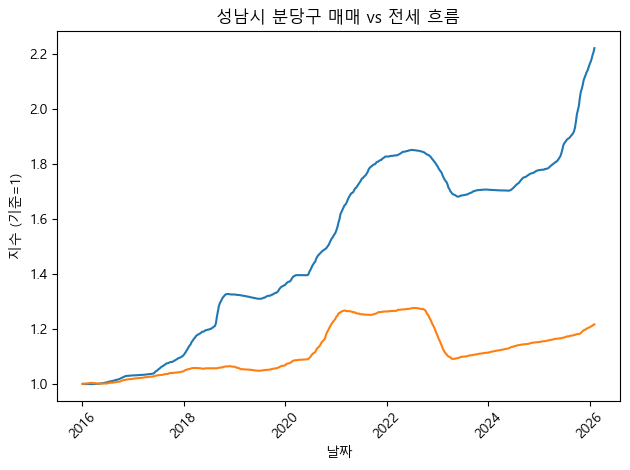

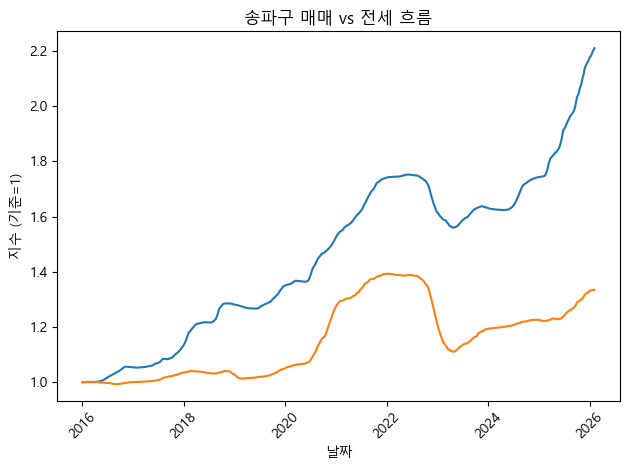

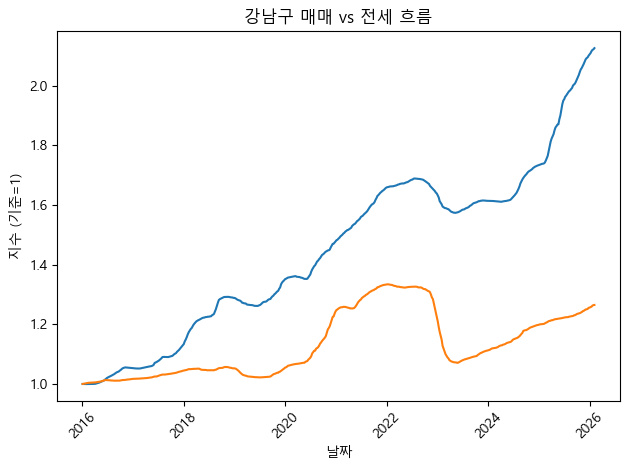

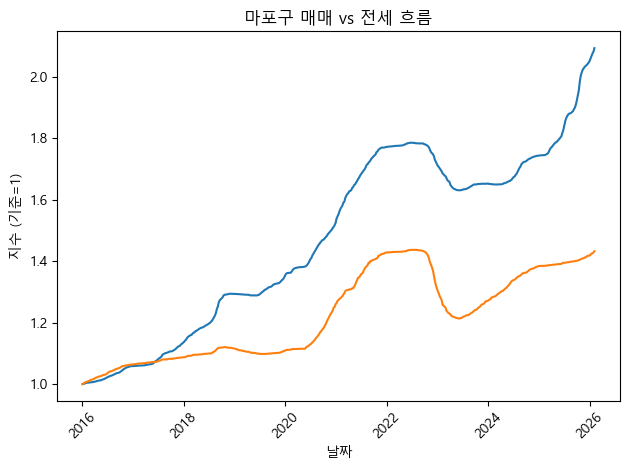

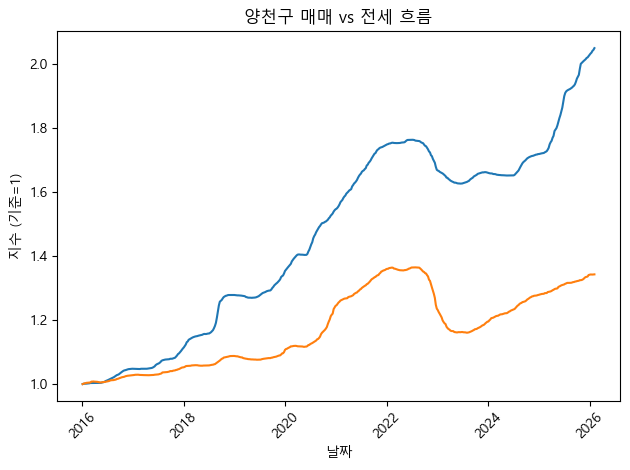

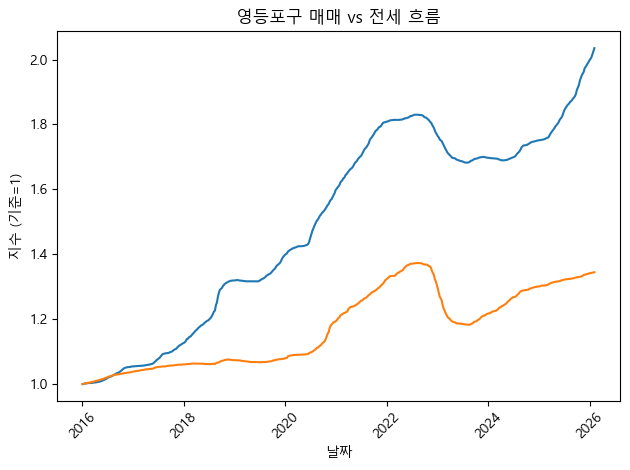

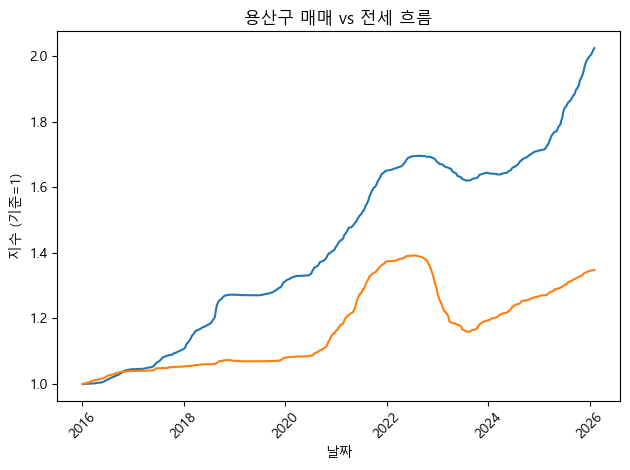

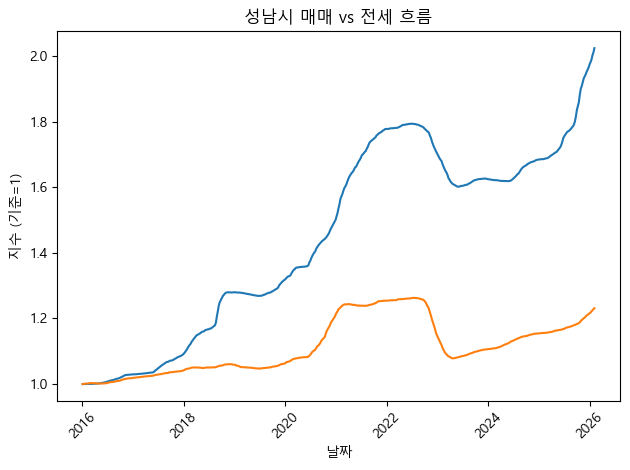

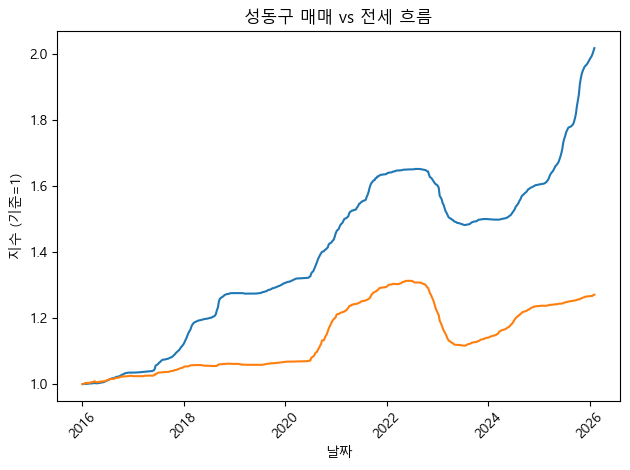

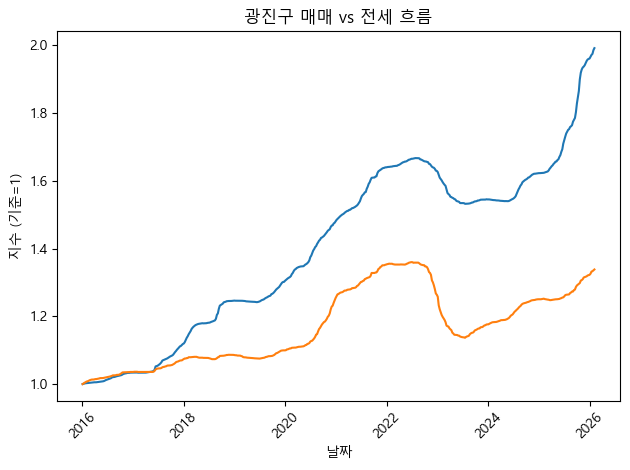

In [ ]:
import matplotlib.pyplot as plt

for region in top10_regions:
    
    region_df = top10_data[top10_data['지역명'] == region].copy()
    
    # 기준값 1로 정규화
    region_df['매매정규화'] = region_df['매매지수'] / region_df['매매지수'].iloc[0]
    region_df['전세정규화'] = region_df['전세지수'] / region_df['전세지수'].iloc[0]
    
    plt.figure()
    plt.plot(region_df['날짜'], region_df['매매정규화'])
    plt.plot(region_df['날짜'], region_df['전세정규화'])
    plt.title(f"{region} 매매 vs 전세 흐름")
    plt.xlabel("날짜")
    plt.ylabel("지수 (기준=1)")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

매매지수와 전세지수를 동일한 기준점으로 맞춘 결과, 일부 지역은 매매가 빠르게 상승한 반면 전세는 상대적으로 완만한 흐름을 보였다.
이러한 구조에서는 전세를 활용한 투자 시 자기자본 수익률이 크게 나타날 수 있다.

C:\Users\Admin\AppData\Local\Temp\ipykernel_11300\1022528925.py:9: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x['매매수익률'].corr(x['전세수익률']))


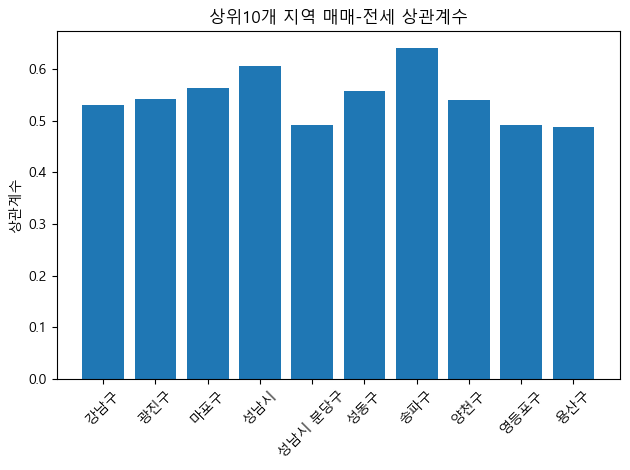

지역명
송파구        0.641293
성남시        0.605852
마포구        0.563036
성동구        0.558234
광진구        0.542213
양천구        0.539364
강남구        0.531192
성남시 분당구    0.492262
영등포구       0.491980
용산구        0.488079
dtype: float64

In [ ]:
# 기간 수익률/가격 변화율 계산
top10_data['매매수익률'] = top10_data.groupby('지역명')['매매지수'].pct_change()
top10_data['전세가격변화율'] = top10_data.groupby('지역명')['전세지수'].pct_change()

# 상관계수 계산
corr = (
    top10_data
    .groupby('지역명')
    .apply(lambda x: x['매매수익률'].corr(x['전세가격변화율']))
)

plt.figure()
plt.bar(corr.index, corr.values)
plt.title("상위10개 지역 매매-전세 상관계수")
plt.xticks(rotation=45)
plt.ylabel("상관계수")
plt.tight_layout()
plt.show()

corr.sort_values(ascending=False)

매매–전세 가격 변화 동조화 분석
- 지역별로 매매가격 변화율과 전세가격 변화율의 상관계수를 계산하여, 두 지표가 함께 움직이는 정도를 확인한다.
- 상관계수가 낮을수록 매매 상승이 전세 상승으로 동일하게 전이되지 않는 구조로, 전세 레버리지를 활용한 투자에 유리할 수 있다.

In [ ]:
#!pip install scikit-learn

   ---------------------------------------- 0.0/8.9 MB ? eta -:--:--
   ------------------------------ --------- 6.8/8.9 MB 38.1 MB/s eta 0:00:01
   ---------------------------------------- 8.9/8.9 MB 32.4 MB/s  0:00:00

   ------------- -------------------------- 1/3 [joblib]
   -------------------------- ------------- 2/3 [scikit-learn]
   -------------------------- ------------- 2/3 [scikit-learn]
   -------------------------- ------------- 2/3 [scikit-learn]
   -------------------------- ------------- 2/3 [scikit-learn]
   -------------------------- ------------- 2/3 [scikit-learn]
   -------------------------- ------------- 2/3 [scikit-learn]
   -------------------------- ------------- 2/3 [scikit-learn]
   -------------------------- ------------- 2/3 [scikit-learn]
   -------------------------- ------------- 2/3 [scikit-learn]
   -------------------------- ------------- 2/3 [scikit-learn]
   -------------------------- ------------- 2/3 [scikit-learn]
   --------------------------

추세 기반 1년/5년/10년 자기자본 수익률 추정
- 과거 매매가격지수의 추세를 선형 회귀로 추정한 뒤, 해당 추세가 1년간 유지된다는 가정하에 지역별 자기자본 수익률을 계산하였다.
- 본 결과는 실제 수익률 예측이 아닌, 지역 간 구조적 차이를 비교하기 위한 참고 지표로 활용한다.

c:\Users\Admin\miniconda3\envs\stats\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
c:\Users\Admin\miniconda3\envs\stats\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
c:\Users\Admin\miniconda3\envs\stats\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
c:\Users\Admin\miniconda3\envs\stats\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
c:\Users\Admin\miniconda3\envs\stats\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted w

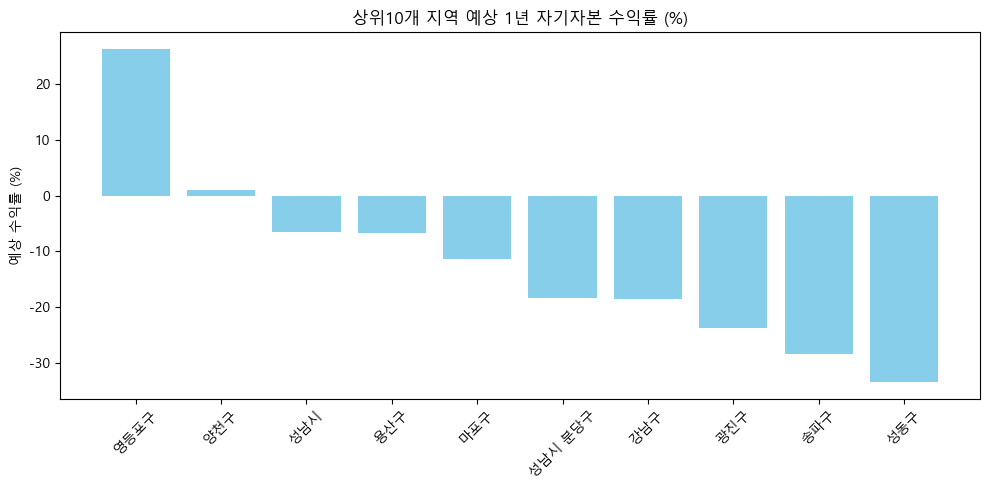

In [ ]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

# top10_regions = 상위 10개 지역 리스트
# top10_data = 매매지수, 전세지수 포함 데이터프레임

future_return = {}

for region in top10_regions:
    region_df = top10_data[top10_data['지역명'] == region].copy()
    region_df = region_df.sort_values('날짜')
    
    # 날짜를 숫자로 변환 (0,1,2,...)
    region_df['주차'] = np.arange(len(region_df))
    
    # 결측치 제거
    region_df = region_df.dropna(subset=['매매지수', '전세지수'])
    
    # 선형회귀: 매매지수 기준 미래 52주 예측
    X = region_df[['주차']]
    y = region_df['매매지수']
    
    model = LinearRegression()
    model.fit(X, y)
    
    # 1년 후 주차
    next_week = np.array([[X['주차'].max() + 52]])
    predicted_price = model.predict(next_week)[0]
    
    # 현재 매매가, 전세가
    current_price = region_df['매매지수'].iloc[-1]
    current_jeonse = region_df['전세지수'].iloc[-1]
    
    # 자기자본 수익률 계산
    equity = current_price - current_jeonse
    predicted_return = (predicted_price - current_price) / equity * 100
    future_return[region] = predicted_return

# 결과 DataFrame
pred_return_df = pd.DataFrame.from_dict(future_return, orient='index', columns=['예상1년수익률(%)'])
pred_return_df = pred_return_df.sort_values('예상1년수익률(%)', ascending=False)

# 그래프
plt.figure(figsize=(10,5))
plt.bar(pred_return_df.index, pred_return_df['예상1년수익률(%)'], color='skyblue')
plt.title("상위10개 지역 예상 1년 자기자본 수익률 (%)")
plt.ylabel("예상 수익률 (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

c:\Users\Admin\miniconda3\envs\stats\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
c:\Users\Admin\miniconda3\envs\stats\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
c:\Users\Admin\miniconda3\envs\stats\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
c:\Users\Admin\miniconda3\envs\stats\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
c:\Users\Admin\miniconda3\envs\stats\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted w

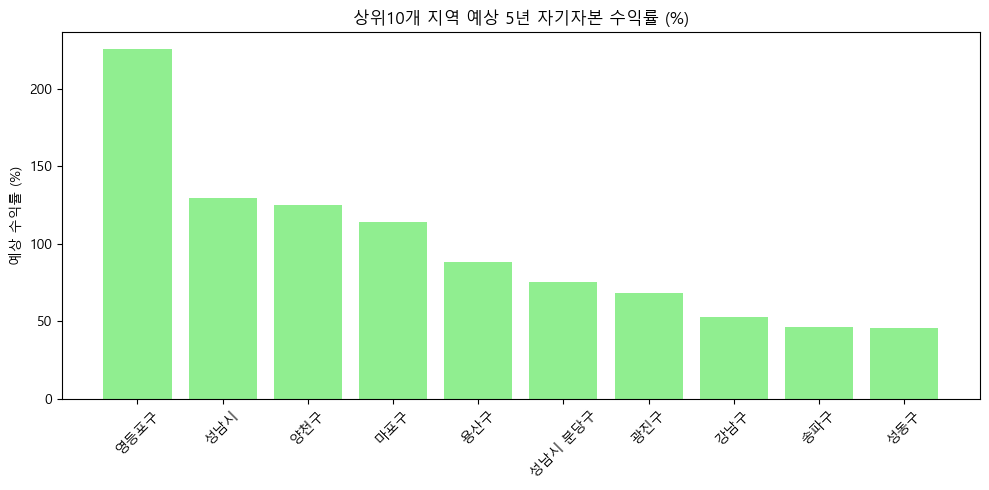

In [ ]:
future_return_5y = {}

for region in top10_regions:
    region_df = top10_data[top10_data['지역명'] == region].copy()
    region_df = region_df.sort_values('날짜')
    
    # 날짜를 숫자로 변환 (0,1,2,...)
    region_df['주차'] = np.arange(len(region_df))
    
    # 결측치 제거
    region_df = region_df.dropna(subset=['매매지수', '전세지수'])
    
    # 선형회귀: 매매지수 기준 미래 5년(260주) 예측
    X = region_df[['주차']]
    y = region_df['매매지수']
    
    model = LinearRegression()
    model.fit(X, y)
    
    # 5년 후 주차
    future_week = np.array([[X['주차'].max() + 260]])
    predicted_price = model.predict(future_week)[0]
    
    # 현재 매매가, 전세가
    current_price = region_df['매매지수'].iloc[-1]
    current_jeonse = region_df['전세지수'].iloc[-1]
    
    # 자기자본 수익률 계산
    equity = current_price - current_jeonse
    predicted_return = (predicted_price - current_price) / equity * 100
    future_return_5y[region] = predicted_return

# 결과 DataFrame
pred_return_5y_df = pd.DataFrame.from_dict(future_return_5y, orient='index', columns=['예상5년수익률(%)'])
pred_return_5y_df = pred_return_5y_df.sort_values('예상5년수익률(%)', ascending=False)

# 그래프
plt.figure(figsize=(10,5))
plt.bar(pred_return_5y_df.index, pred_return_5y_df['예상5년수익률(%)'], color='lightgreen')
plt.title("상위10개 지역 예상 5년 자기자본 수익률 (%)")
plt.ylabel("예상 수익률 (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

c:\Users\Admin\miniconda3\envs\stats\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
c:\Users\Admin\miniconda3\envs\stats\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
c:\Users\Admin\miniconda3\envs\stats\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
c:\Users\Admin\miniconda3\envs\stats\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
c:\Users\Admin\miniconda3\envs\stats\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted w

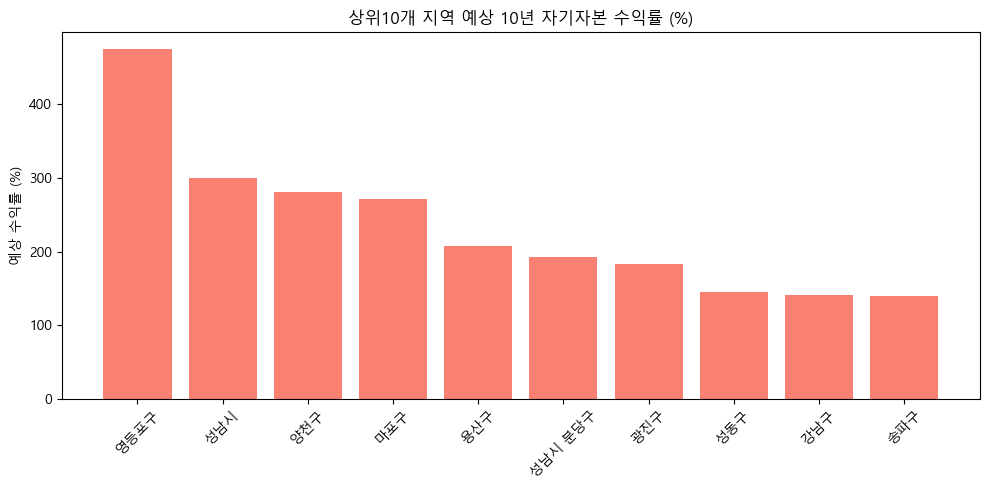

In [ ]:
# 10년 투자 기준
future_return_10y = {}

for region in top10_regions:
    region_df = top10_data[top10_data['지역명'] == region].copy()
    region_df = region_df.sort_values('날짜')
    region_df['주차'] = np.arange(len(region_df))
    region_df = region_df.dropna(subset=['매매지수', '전세지수'])
    
    X = region_df[['주차']]
    y = region_df['매매지수']
    
    model = LinearRegression()
    model.fit(X, y)
    
    # 10년 후 주차
    future_week = np.array([[X['주차'].max() + 520]])
    predicted_price = model.predict(future_week)[0]
    
    current_price = region_df['매매지수'].iloc[-1]
    current_jeonse = region_df['전세지수'].iloc[-1]
    
    equity = current_price - current_jeonse
    predicted_return = (predicted_price - current_price) / equity * 100
    future_return_10y[region] = predicted_return

# 결과 DataFrame
pred_return_10y_df = pd.DataFrame.from_dict(future_return_10y, orient='index', columns=['예상10년수익률(%)'])
pred_return_10y_df = pred_return_10y_df.sort_values('예상10년수익률(%)', ascending=False)

# 그래프
plt.figure(figsize=(10,5))
plt.bar(pred_return_10y_df.index, pred_return_10y_df['예상10년수익률(%)'], color='salmon')
plt.title("상위10개 지역 예상 10년 자기자본 수익률 (%)")
plt.ylabel("예상 수익률 (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

영등포가 강남·분당보다 수익률이 높게 나오는 이유 가능성

자기자본 비율 효과(레버리지 효과)

영등포는 전세가가 매매가 대비 상대적으로 높지 않거나, 최근 상승폭이 덜한 경우 자기자본(매매가-전세가)이 작습니다.

동일 매매가 상승률이라도 자기자본이 작으면 수익률이 크게 나타나는 구조입니다.

최근 매매가 상승률이 빠름

강남/분당은 이미 가격이 높아 절대 상승폭은 커도 상대적 자기자본 수익률은 낮게 나타날 수 있음.

영등포는 최근 개발/재개발 호재로 가격 상승이 빠를 수 있음.

전세 시장 안정성

영등포는 전세 수요 대비 공급이 상대적으로 많아 전세가 상승폭이 제한될 수 있음.

전세금이 낮으면 자기자본이 작아 수익률이 체감상 높게 나오는 현상이 생김.

모델 단순화 영향

지금 Linear Regression으로 장기 예측 시 과거 추세가 그대로 이어진다고 가정.

강남/분당처럼 이미 고평가된 지역은 장기 선형 상승률 예측이 제한적일 수 있음.

즉, “자기자본이 작고 매매가 상승폭이 크면 수익률이 높게 나오는 구조” 때문에 영등포가 상대적으로 수익률이 높게 나올 수 있습니다.